# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 

warnings.filterwarnings('ignore')

# Load Data

In [2]:
df = pd.read_csv('./Dataset A/3A.tsv', delimiter='\t', index_col='index')

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
index,,,,,,,,,,,,,,,,
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,-706.0,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,-92.0,NaN,NaN


In [3]:
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release       0
Genre                 2
Publisher            55
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8668
Critic_Count       8668
User_Score         6769
User_Count            0
Developer          6688
Rating             6836
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16928 entries, 0 to 16927
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16926 non-null  object 
 1   Platform         16928 non-null  object 
 2   Year_of_Release  16928 non-null  int64  
 3   Genre            16926 non-null  object 
 4   Publisher        16873 non-null  object 
 5   NA_Sales         16928 non-null  float64
 6   EU_Sales         16928 non-null  float64
 7   JP_Sales         16928 non-null  float64
 8   Other_Sales      16928 non-null  float64
 9   Global_Sales     16928 non-null  float64
 10  Critic_Score     8260 non-null   float64
 11  Critic_Count     8260 non-null   float64
 12  User_Score       10159 non-null  object 
 13  User_Count       16928 non-null  float64
 14  Developer        10240 non-null  object 
 15  Rating           10092 non-null  object 
dtypes: float64(8), int64(1), object(7)
memory usage: 2.2+ MB


In [5]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16928.000000,16928.000000,16928.000000,16928.000000,16928.000000,16928.000000,8260.000000,8260.000000,16928.000000
mean,1974.215147,0.266390,0.146850,0.078170,0.047861,0.539520,69.037893,26.428692,-195.792120
std,252.128480,0.814326,0.504585,0.308756,0.186675,1.550545,13.943198,18.989929,545.393536
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,-1000.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,-538.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,22.000000,-82.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.040000,0.490000,79.000000,36.000000,21.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [6]:
# Check Unique Values
for col in df.columns:
    print(f'{col} : {df[col].unique()}')
    print()

Name : ['Wii Sports' 'Super Mario Bros.' 'Mario Kart Wii' ...
 'Woody Woodpecker in Crazy Castle 5' 'LMA Manager 2007'
 'Haitaka no Psychedelica']

Platform : ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']

Year_of_Release : [2006 1985 2008 2009 1996 1989 1984 2005 1999 2007 2010 2013 2004 1990
 1988 2002 2001 2011 1998 2015 2012 2014 1992 1997 1993 1994 1982 2016
 2003 1986 2000    6 1995 1991 1981 1987 1980    8 1983    7    1    4
    2    5   10    3    9 2020 2017]

Genre : ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]

Publisher : ['Nintendo' 'Microsoft Game Studios' 'Take-Two Interactive'
 'Sony Computer Entertainment' 'Activision' 'Ubisoft' 'Bethesda Softworks'
 'Electronic Arts' 'Sega' 'SquareSoft' 'Atari' '505 Games' 'Capcom'
 'GT Interactive' 'Konami D

# Data Cleaning

- 'User_Score' converted to numeric and cleaned of invalid entries ('tbd').
- Missing values in 'Name', 'Genre', 'Publisher', 'Developer', and 'Rating' replaced with 'Unknown'.
- 'Critic_Score' and 'User_Score' filled with their respective column means.
- Rows with invalid or missing 'Year_of_Release', negative 'User_Count', and missing 'Critic_Count' removed.

In [7]:
# Cleaning the dataset

# Convert 'User_Score' to numeric, replacing 'tbd' with NaN
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Handle missing values by filling or dropping based on relevance
data_cleaned = df.copy()
columns_to_fill = ['Name', 'Genre', 'Publisher', 'Developer', 'Rating']
for column in columns_to_fill:
    data_cleaned[column].fillna('Unknown', inplace=True)

# Fill 'Critic_Score' and 'User_Score' with their respective means
data_cleaned['Critic_Score'].fillna(data_cleaned['Critic_Score'].mean(), inplace=True)
data_cleaned['User_Score'].fillna(data_cleaned['User_Score'].mean(), inplace=True)

# Drop rows with missing 'Year_of_Release' or invalid 'User_Count'  or 'Critic_Count'
data_cleaned = data_cleaned[data_cleaned['Year_of_Release'] > 0]
data_cleaned = data_cleaned[data_cleaned['User_Count'] > 0]
data_cleaned = data_cleaned[data_cleaned['Critic_Count'] > 0]

# Check the cleaned dataset
data_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7134 entries, 0 to 16926
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             7134 non-null   object 
 1   Platform         7134 non-null   object 
 2   Year_of_Release  7134 non-null   int64  
 3   Genre            7134 non-null   object 
 4   Publisher        7134 non-null   object 
 5   NA_Sales         7134 non-null   float64
 6   EU_Sales         7134 non-null   float64
 7   JP_Sales         7134 non-null   float64
 8   Other_Sales      7134 non-null   float64
 9   Global_Sales     7134 non-null   float64
 10  Critic_Score     7134 non-null   float64
 11  Critic_Count     7134 non-null   float64
 12  User_Score       7134 non-null   float64
 13  User_Count       7134 non-null   float64
 14  Developer        7134 non-null   object 
 15  Rating           7134 non-null   object 
dtypes: float64(9), int64(1), object(6)
memory usage: 947.5+ KB


In [8]:
data_cleaned.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
index,,,,,,,,,,,,,,,,
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E


In [9]:
data_cleaned.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

# EDA

In [10]:
# Setting visual styles
sns.set(style="whitegrid")


## 1. Top 10 genres by global sales

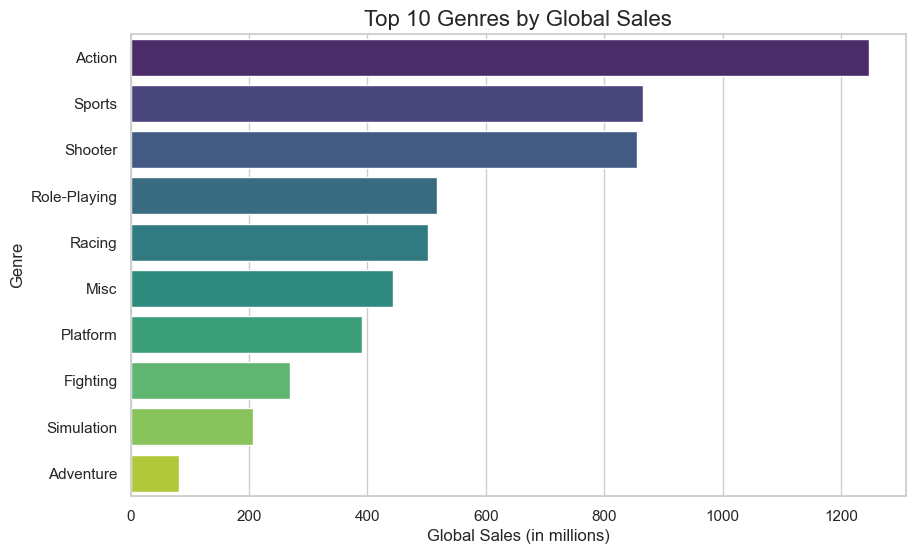

In [11]:
top_genres = (
    data_cleaned.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 10 Genres by Global Sales", fontsize=16)
plt.xlabel("Global Sales (in millions)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.show()

The most successful genre globally is Action, followed by Sports and Shooter.
These genres dominate a significant portion of the gaming market.

## 2. Global sales trends over the years

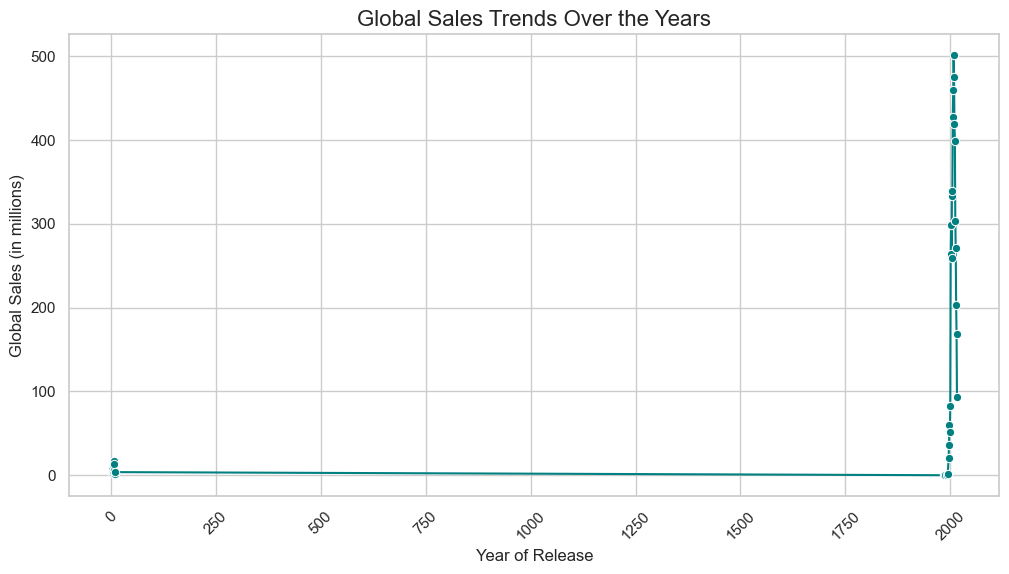

In [12]:
sales_trend = data_cleaned.groupby("Year_of_Release")["Global_Sales"].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_trend.index, y=sales_trend.values, marker="o", color="teal")
plt.title("Global Sales Trends Over the Years", fontsize=16)
plt.xlabel("Year of Release", fontsize=12)
plt.ylabel("Global Sales (in millions)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

Sales peaked in the late 2000s, with a noticeable decline in the following years.
The decline might align with shifts in the gaming industry, such as the rise of mobile gaming or digital-only platforms.

## 3. Distribution of Critic and User Scores


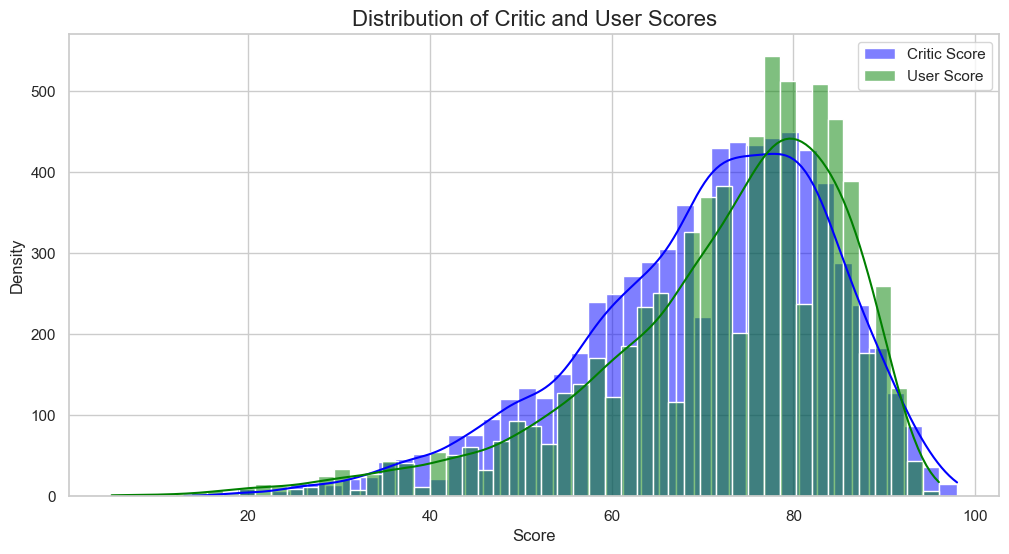

In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(data_cleaned["Critic_Score"], kde=True, color="blue", label="Critic Score")
sns.histplot(data_cleaned["User_Score"] * 10, kde=True, color="green", label="User Score")
plt.title("Distribution of Critic and User Scores", fontsize=16)
plt.xlabel("Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()


Critic scores generally cluster between 60 and 90, with a relatively normal distribution.
User scores (scaled to the same range) are more widely distributed, reflecting diverse opinions.

# Content-Based Recommendation System

The recommendation system uses the game's genre, platform, and publisher to suggest similar games.

## Combining Features to a single string for each game (Content)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Content-based recommendation using Genre, Platform, Name, and Developer

# Combine relevant features into a single string for each game
data_cleaned["content"] = (
    data_cleaned['Name'] + " " + data_cleaned["Genre"] + " " + data_cleaned["Platform"] + " " + data_cleaned["Developer"].fillna("Unknown")
)

## Vectorize the content feature


In [25]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(data_cleaned["content"])

## Compute cosine similarity matrix

In [26]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

## Content-Based Recommendation Function

In [50]:
def get_recommendations(prompt, cosine_sim=cosine_sim):
    # Get the index of the game that matches the prompt
    if data_cleaned[data_cleaned["Name"].str.contains(prompt, case=False, na=False)].empty:
        if data_cleaned[data_cleaned["Genre"].str.contains(prompt, case=False, na=False)].empty:
            if data_cleaned[data_cleaned["Platform"].str.contains(prompt, case=False, na=False)].empty:
                idx = data_cleaned[data_cleaned["Developer"].str.contains(prompt, case=False, na=False)].index[0]
            else:
                idx = data_cleaned[data_cleaned["Platform"].str.contains(prompt, case=False, na=False)].index[0]
        else:
            idx = data_cleaned[data_cleaned["Genre"].str.contains(prompt, case=False, na=False)].index[0]
    else:
        idx = data_cleaned[data_cleaned["Name"].str.contains(prompt, case=False, na=False)].index[0]
    
    # Get the pairwise similarity scores of all games with that game
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # Sort the games based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get the indices of the top 10 most similar games
    sim_indices = [i[0] for i in sim_scores[1:11]]
    
    # Return the top 10 most similar games
    return data_cleaned.iloc[sim_indices][["Name", "Genre", "Platform", "Developer", "Global_Sales"]]


## Example of Content-Based Recommendation

In [51]:
# Example: Recommend games similar to "Super Mario"
recommendations = get_recommendations("Super Mario")
recommendations

,Name,Genre,Platform,Developer,Global_Sales
index,,,,,
110,Mario Kart 8,Racing,WiiU,Nintendo,7.09
16726,Mario Kart 8,Racing,WiiU,Nintendo,7.09
2,Mario Kart Wii,Racing,Wii,Nintendo,35.52
787,Tetris DS,Puzzle,DS,Nintendo,2.10
6,New Super Mario Bros.,Platform,DS,Nintendo,29.80
74,Mario Party DS,Misc,DS,Hudson Soft,8.91
166,Mario Kart: Super Circuit,Racing,GBA,Intelligent Systems,5.47
4587,NASCAR Kart Racing,Racing,Wii,Electronic Arts,0.42
1704,Mario vs. Donkey Kong 2: March of the Minis,Puzzle,DS,"Nintendo, Nintendo Software Technology",1.19


In [52]:
recommendations = get_recommendations("Wii")
recommendations

,Name,Genre,Platform,Developer,Global_Sales
index,,,,,
3,Wii Sports Resort,Sports,Wii,Nintendo,32.77
13,Wii Fit,Sports,Wii,Nintendo,22.70
5058,Wii Sports Club,Sports,WiiU,Nintendo,0.38
418,Wii Music,Misc,Wii,Nintendo,3.25
15,Wii Fit Plus,Sports,Wii,Nintendo,21.79
7,Wii Play,Misc,Wii,Nintendo,28.92
2,Mario Kart Wii,Racing,Wii,Nintendo,35.52
2445,Wii Fit U,Sports,WiiU,Nintendo,0.85
2257,Wii Play: Motion,Misc,Wii,Nintendo,0.92


In [57]:
recommendations = get_recommendations("Warriors")
recommendations

,Name,Genre,Platform,Developer,Global_Sales
index,,,,,
1296,Fight Night Round 3,Fighting,X360,EA Chicago,1.47
1094,Fight Night Round 3,Fighting,PS3,EA Chicago,1.67
5487,Fight Night Round 3,Fighting,XB,EA Chicago,0.33
3856,Fight Night Round 3,Fighting,PSP,EA Chicago,0.52
2400,Fight Night Round 2,Fighting,PS2,EA Sports,0.87
3331,Fight Night Round 2,Fighting,XB,EA Sports,0.60
16926,Fight Night Round 2,Fighting,XB,EA Sports,0.60
8260,Fight Night Round 2,Fighting,GC,EA Sports,0.17
1374,Fight Night Round 4,Fighting,X360,EA Canada,1.40


# Conclusion

The content-based recommendation system can suggest games similar to a given game based on its genre, platform, and publisher. This system can help users discover new games based on their preferences. but it does not consider user ratings or popularity. For a more personalized recommendation, collaborative filtering or hybrid systems could be explored.